In [2]:
# libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import OneHotEncoder,LabelBinarizer

from keras.models import Sequential
from keras.layers import Dense, Input, Dropout
from keras import callbacks
import tensorflow as tf
from tensorflow.keras import initializers
from keras.regularizers import l2,l1,l1_l2
from sklearn.metrics import f1_score
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np
from sklearn.metrics import top_k_accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, Flatten, Conv2D, MaxPooling2D, AveragePooling2D
from tensorflow.keras.layers import (
    Dense, Flatten, Conv2D, MaxPooling2D, AveragePooling2D,
    Dropout, BatchNormalization, Input
)
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import KFold#, StratifiedKFold
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, GlobalAveragePooling2D

>In this notebook we create a CNN model and train it on an image based dataset(fashion_mnist). Then we analyse the effect of each CNN component. After that we use data augmentation techniques and  transfer learning models on our data.

## Preprocessing Dataset

>The fashion mnist dataset consists of images of cloths, the task is to classify them into 10 classes. So we are dealing with a multi-class classification problem.

In [3]:
# Fashion-MNIST - Clothing items
(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()

In [4]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


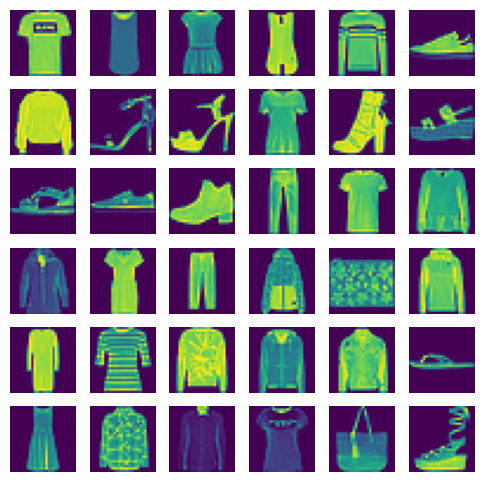

In [4]:
fig, ax = plt.subplots(nrows=6, ncols=6, figsize=(6,6))
itr = 0
for i in range(0,6):
  for j in range(0,6):
    itr += 1

    # convert to unsigned integers
    image = x_train[itr,:,:]

    # plot image
    ax[i,j].imshow(image)
    ax[i,j].axis('off')

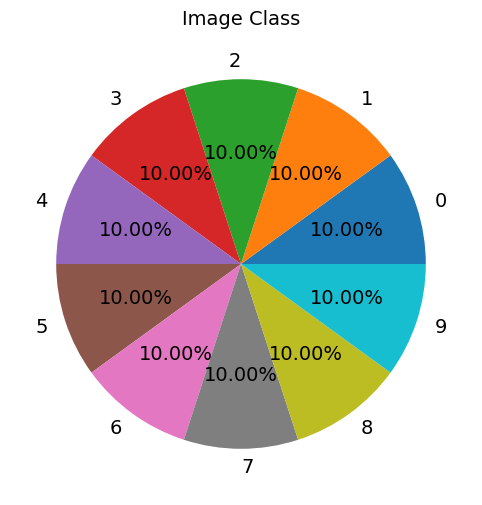

In [5]:
# Pie chart
y_df = pd.DataFrame(y_train)
selected_labels = range(0,10)
y_df.value_counts().plot(
    kind = 'pie',figsize=(12,6),autopct='%1.2f%%',ylabel='',radius=1,labels=selected_labels,fontsize=14)

plt.title("Image Class",fontsize=14)
plt.show()


In [5]:
# Normalization
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

In [6]:
print(f"Before: {y_train[0]}")  # Output: 9

# Convert to binary format
enc = LabelBinarizer()
y_train_enc = enc.fit_transform(y_train)
y_test_enc = enc.transform(y_test)

Before: 9


## Creating CNN Model

In [7]:
# early stopping
early_stopping = callbacks.EarlyStopping(
    min_delta=0.001,           # minimium amount of change to be considered an improvement
    patience=10,               # number of epochs to wait before deciding there is no significant improvement in training
    restore_best_weights=True,
)

In [8]:
def create_model(
    hidden_layers: list = ['Conv2D_3x3_32_1', 'BatchNorm', 'Conv2D_3x3_64_1',
                           'BatchNorm', 'MaxPooling2D_2x2_2', 'Dropout_0.25',
                           'Conv2D_3x3_128_1', 'BatchNorm', 'MaxPooling2D_2x2_2',
                           'Dropout_0.25', 'Flatten', 'Dense_256', 'BatchNorm',
                           'Dropout_0.5', 'Dense_128', 'BatchNorm', 'Dropout_0.3'],
    input_size=None,
    no_classes=10,
    activation_func: str = 'relu',
    l1_reg: float = 0.0,
    l2_reg: float = 0.0001,
    learning_rate: float = 0.001,
    weight_initializer: str = 'GlorotUniform',
    optimizer_name: str = 'adam',
    regularization_type: str = 'kernel_regularizer'
):


    # ── Weight initializer ──────────────────────────────────────────────────
    init_map = {
        'RandomNormal':  initializers.RandomNormal(),
        'RandomUniform': initializers.RandomUniform(),
        'Zeros':         initializers.Zeros(),
        'GlorotUniform': initializers.GlorotUniform(),
        'GlorotNormal':  initializers.GlorotNormal(),
        'HeNormal':      initializers.HeNormal(),
        'HeUniform':     initializers.HeUniform(),
    }
    weight_init = init_map.get(weight_initializer, initializers.GlorotUniform())

    # ── Regularizer helper ──────────────────────────────────────────────────
    def get_regularizer():
        if l1_reg and l2_reg:
            return l1_l2(l1=l1_reg, l2=l2_reg)
        elif l1_reg:
            return l1(l1_reg)
        elif l2_reg:
            return l2(l2_reg)
        return None

    reg = get_regularizer()

    def reg_kwargs(reg_type):
        
        if reg is None:
            return {}
        if reg_type == 'activation_regularizer':
            return {'activity_regularizer': reg}
        return {'kernel_regularizer': reg}

    # ── Build model ─────────────────────────────────────────────────────────
    model = Sequential()

    if input_size is not None:
        model.add(Input(shape=input_size))

    for layer_spec in hidden_layers:
        parts = layer_spec.split('_')
        layer_type = parts[0]

        # ── Dense ──────────────────────────────────────────────────────────
        if layer_type == 'Dense':
            n_neurons = int(parts[1])
            model.add(Dense(
                n_neurons,
                activation=activation_func,
                kernel_initializer=weight_init,
                **reg_kwargs(regularization_type)
            ))

        # ── Conv2D ─────────────────────────────────────────────────────────
        elif layer_type == 'Conv2D':
            # Format: Conv2D_<KHxKW>_<filters>_<stride>
            kernel_h, kernel_w = map(int, parts[1].split('x'))
            filters  = int(parts[2])
            stride   = int(parts[3]) if len(parts) > 3 and parts[3] != '0' else 1

            model.add(Conv2D(
                filters=filters,
                kernel_size=(kernel_h, kernel_w),
                strides=stride,
                activation=activation_func,
                padding='same',             
                kernel_initializer=weight_init,
                **reg_kwargs(regularization_type)
            ))

        # ── Pooling ────────────────────────────────────────────────────────
        elif 'Pooling2D' in layer_type:
            pool_h, pool_w = map(int, parts[1].split('x'))
            stride = int(parts[2]) if len(parts) > 2 and parts[2] != '0' else None

            if layer_type == 'MaxPooling2D':
                model.add(MaxPooling2D(pool_size=(pool_h, pool_w), strides=stride))
            elif layer_type == 'AveragePooling2D':
                model.add(AveragePooling2D(pool_size=(pool_h, pool_w), strides=stride))

        # ── Flatten ────────────────────────────────────────────────────────
        elif layer_type == 'Flatten':
            model.add(Flatten())

        # ── BatchNormalization ─────────────────────────────────────────────
        elif layer_type == 'BatchNorm':
            model.add(BatchNormalization())

        # ── Dropout (explicit rate in spec) ───────────────────────────────
        elif layer_type == 'Dropout':
            rate = float(parts[1])
            model.add(Dropout(rate))

    # ── Output layer ────────────────────────────────────────────────────────
    model.add(Dense(no_classes, activation='softmax'))

    # ── Optimizer ───────────────────────────────────────────────────────────

    if optimizer_name == 'sgd':
        optimizer = tf.keras.optimizers.SGD(
            learning_rate=learning_rate, momentum=0.9, nesterov=True
        )
    elif optimizer_name == 'RMSprop':
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    elif optimizer_name == 'Adadelta':
        optimizer = tf.keras.optimizers.Adadelta(learning_rate=learning_rate, rho=0.95)
    else:
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=learning_rate,
            beta_1=0.9,
            beta_2=0.999,
        )

    model.compile(
        loss='categorical_crossentropy',
        optimizer=optimizer,
        metrics=['accuracy']
    )

    return model

In [9]:
# plot history
def plot_history(history, plot_type='loss', figsize=(15,5)):

    hist_df = pd.DataFrame(history.history)
    plt.figure(figsize=figsize)

    if plot_type == 'loss':
        # Plot loss curves
        plt.plot(hist_df['loss'], 'b-', label='Training Loss', lw=2)
        if 'val_loss' in hist_df:
            plt.plot(hist_df['val_loss'], 'r-', label='Validation Loss', lw=2)
            best = hist_df['val_loss'].idxmin()
            plt.axvline(best, color='gray', linestyle='--', alpha=0.5)

    elif plot_type == 'acc':
        # Plot accuracy curves
        plt.plot(hist_df['accuracy'], 'g-', label='Training Accuracy', lw=2)
        if 'val_accuracy' in hist_df:
            plt.plot(hist_df['val_accuracy'], 'orange', label='Validation Accuracy', lw=2)
            best = hist_df['val_accuracy'].idxmax()
            plt.axvline(best, color='gray', linestyle='--', alpha=0.5)

    else:  # precision & recall
        for metric in ['precision', 'recall']:
            if metric in hist_df:
                plt.plot(hist_df[metric], 'b-' if metric=='precision' else 'b--',
                        label=f'Training {metric.title()}', lw=2)
            if f'val_{metric}' in hist_df:
                plt.plot(hist_df[f'val_{metric}'], 'r-' if metric=='precision' else 'r--',
                        label=f'Validation {metric.title()}', lw=2)

    plt.title(f'Model {plot_type.upper()}')
    plt.xlabel('Epochs')
    plt.ylabel(plot_type.upper())
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [10]:
model = create_model(
        hidden_layers=[
            'Conv2D_3x3_32_1',      # 28×28×32
            'BatchNorm',
            'Conv2D_3x3_64_1',      # 28×28×64
            'BatchNorm',
            'MaxPooling2D_2x2_2',   # 14×14×64
            'Dropout_0.25',

            'Conv2D_3x3_128_1',     # 14×14×128
            'BatchNorm',
            'MaxPooling2D_2x2_2',   # 7×7×128
            'Dropout_0.25',

            'Flatten',              # 6272

            'Dense_256',
            'BatchNorm',
            'Dropout_0.5',

            'Dense_128',
            'BatchNorm',
            'Dropout_0.3',
        ],
        input_size=(28, 28, 1),
        no_classes=10,
        activation_func='relu',
        l2_reg=0.0001,
        learning_rate=0.001,
        weight_initializer='HeNormal',
        optimizer_name='adam',
    )
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,735,178 (6.62 MB)

 Trainable params: 1,733,962 (6.61 MB)

 Non-trainable params: 1,216 (4.75 KB)

## Training & Evaluation

In [11]:
callbacks = [
        # Halve LR when val_loss plateaus for 5 epochs
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=5, min_lr=1e-6, verbose=1
        ),
        # Stop early if val_loss doesn't improve for 10 epochs
        EarlyStopping(
            monitor='val_loss', patience=10,
            restore_best_weights=True, verbose=1
        ),
    ]
history = model.fit(
        x_train, y_train_enc,
        epochs=2,
        batch_size=64,
        validation_split=0.2,
        callbacks=callbacks
    )

Epoch 1/2
750/750 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.8254 - loss: 0.6473 - val_accuracy: 0.8924 - val_loss: 0.4556 - learning_rate: 0.0010
Epoch 2/2
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8853 - loss: 0.4772 - val_accuracy: 0.9102 - val_loss: 0.4080 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 2.


In [15]:
predictions = model.predict(x_test)
output = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [14]:

print('Weighted F1-score is %.2f' %f1_score(y_test, output, average='weighted'))


Weighted F1-score is 0.90


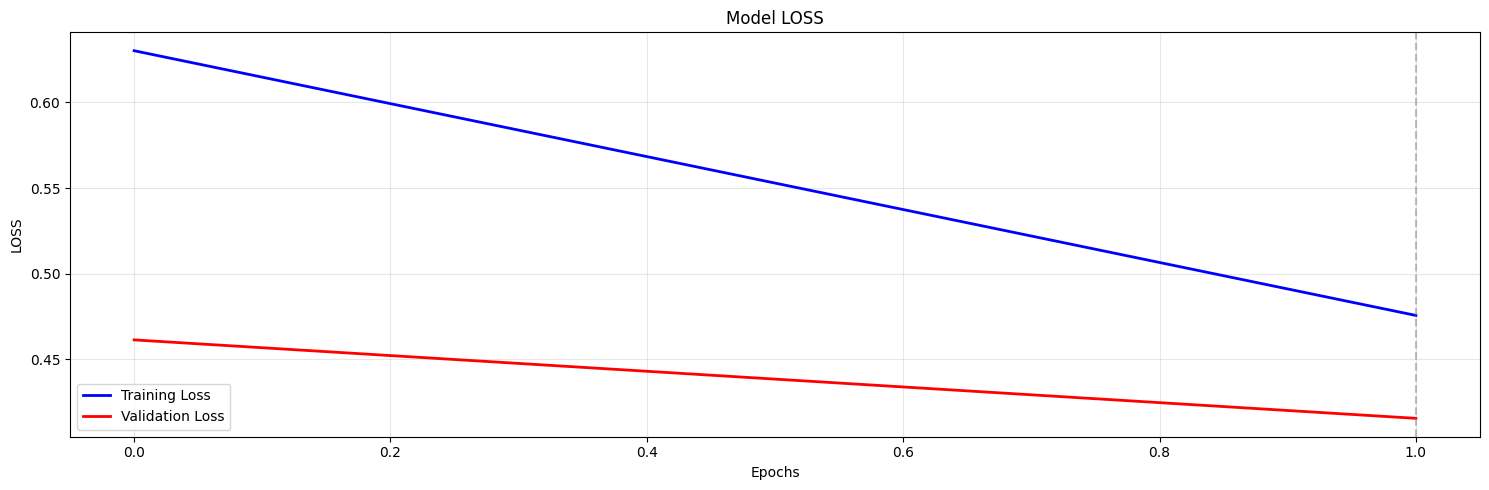

In [15]:
plot_history(history,plot_type='loss')

In [16]:
print('Top-3 accuracy %.2f' %top_k_accuracy_score(y_test, predictions, k=3))

Top-3 accuracy 0.99


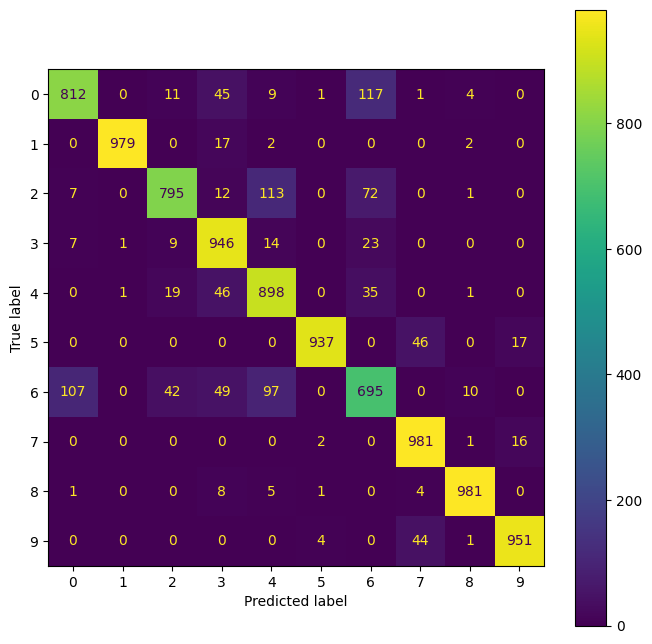

In [17]:
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(y_test, output,ax=ax)
plt.show()

## CNN Components Analysis

In [12]:
def convert_predictions(pred):
    if pred.ndim == 2:
        # Multi-class: take argmax over class probabilities
        return np.argmax(pred, axis=1)
    else:
        # Binary: threshold probabilities at 0.5
        return (pred > 0.5).astype(int)

In [13]:
def kfold_validation(no_folds: int=3, plot_results: bool=True,
                     model_params: dict={},training_params: dict={}):
  validation_set_accuracy = []
  models = []

  if plot_results:
    verbose=2
  else:
    verbose=0

  itr = 0
  kf = KFold(n_splits=no_folds)
  for train_index, val_index in kf.split(x_train,y_train):
    train_set, y_train_set = x_train[train_index,:,:,:], y_train_enc[train_index]
    val_set,y_val = x_train[val_index,:,:,:], y_train_enc[val_index]

    # First, create a new model
    model = create_model(**model_params)
    #model.summary()

    # Finally, let's fit the model
    history = model.fit(train_set, y_train_set,
                      validation_data=(val_set,y_val),
                      callbacks=[early_stopping],
                      verbose=verbose,
                      **training_params,
                      )


    # Finally, let's
    pred_val = model.predict(val_set)
    f1 = f1_score(convert_predictions(y_val), convert_predictions(pred_val), average='weighted')

    validation_set_accuracy.append(f1)
    models.append(model)

    # Plot the results
    if plot_results:
      plot_history(history,plot_type='acc')


  # Convert to numpy array
  validation_set_accuracy = np.array(validation_set_accuracy)

  # Return the best model (as an example)
  ind = np.argmax(validation_set_accuracy)
  best_model = models[ind]

  # Delete remaining models
  models.remove(best_model)
  for m in models:
    del m

  # Print the reults
  if plot_results:
    print('Average F1-Score over validation set is %.2f' %validation_set_accuracy.mean())
    print('STD of F1-Score over validation set is %.2f' %validation_set_accuracy.std())
  return best_model,validation_set_accuracy.mean(),validation_set_accuracy.std()

In [14]:
def evaluate_efect_param(parameter_type: str='kfold', parameter_name: str='', values_list: list=[]):
  scores_val = []
  scores_test = []
  models = []
  for val in values_list:

      if parameter_type == 'kfold':
        kfold_params[parameter_name] = val
      elif parameter_type == 'model_params':
        kfold_params['model_params'][parameter_name] = val
      elif parameter_type == 'training_params':
        kfold_params['training_params'][parameter_name] = val

      model,validation_set_accuracy_mean,validation_set_accuracy_std = kfold_validation(**kfold_params)

      scores_val.append(validation_set_accuracy_mean)

      predictions = model.predict(x_test)
      score_test = f1_score(convert_predictions(y_test), convert_predictions(predictions), average='weighted')
      scores_test.append(score_test)

      models.append(model)
      print('Val: %s, Validation Score: %.3f, Test Score: %.3f' %(str(val),validation_set_accuracy_mean,score_test))


  # Plot the results
  plt.figure(figsize=(20,8))
  str_values_list = []
  for v in values_list:
    str_values_list.append(str(v))

  plt.plot(str_values_list,scores_test,lw=5)
  plt.plot(str_values_list,scores_val,lw=5,color='orange')
  plt.xlabel(parameter_name)
  plt.ylabel('F1-Score')
  plt.legend(['F1: Test Set','F1: Validation Set'])
  plt.show()

  # Get the best model
  ind = np.argmax(scores_val)
  best_model = models[ind]

  best_val = values_list[np.argmax(scores_val)]

  # Delete remaining models
  models.remove(best_model)
  for m in models:
    del m

  return best_model,best_val


In [15]:
kfold_params = {
    'no_folds': 3,
    'plot_results': False,
    'model_params': {
    'hidden_layers': ['Conv2D_3x3_32_1', 'BatchNorm', 'Conv2D_3x3_64_1',
                           'BatchNorm', 'MaxPooling2D_2x2_2', 'Dropout_0.25',
                           'Conv2D_3x3_128_1', 'BatchNorm', 'MaxPooling2D_2x2_2',
                           'Dropout_0.25', 'Flatten', 'Dense_256', 'BatchNorm',
                           'Dropout_0.5', 'Dense_128', 'BatchNorm', 'Dropout_0.3'],
      'activation_func': 'relu',
      'l1_reg': 0,
      'l2_reg': 0,
      'learning_rate': 0.001,
      'weight_initializer': 'GlorotNormal',
      'optimizer_name': 'adam',
      'regularization_type': 'kernel_regularizer',
  },
  'training_params': {
    'batch_size': 64,
    'epochs': 2
  }
}

In [52]:
model,validation_set_accuracy_mean,validation_set_accuracy_std = kfold_validation(**kfold_params)

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [27]:
print(validation_set_accuracy_mean,validation_set_accuracy_std)

0.8830196514972029 0.01666814427329806


1. Kernel Size

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Val: ['Conv2D_3x3_32_1', 'BatchNorm', 'Conv2D_3x3_64_1', 'BatchNorm', 'MaxPooling2D_2x2_2', 'Dropout_0.25', 'Conv2D_3x3_128_1', 'BatchNorm', 'MaxPooling2D_2x2_2', 'Dropout_0.25', 'Flatten', 'Dense_256', 'BatchNorm', 'Dropout_0.5', 'Dense_128', 'BatchNorm', 'Dropout_0.3'], Validation Score: 0.865, Test Score: 0.263
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Val: ['Conv2D_5x5_32_1', 'BatchNorm', 'Conv2D_5x5_64_1', 'BatchNorm', 'MaxPooling2D_2x2_2', 'Dropout_0.25', 'Conv2D_5x5_128_1', 'BatchNorm', 'MaxPooling2D_2x2_2', 'Dropout_0.25', 'Flatten', 'Dense_256', 'BatchNorm', 'Dropout_0.5', 'Dense_128', 'BatchNorm', 'Dropout_0.3'], Validation Score: 0.866, Test Score: 0.252
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step

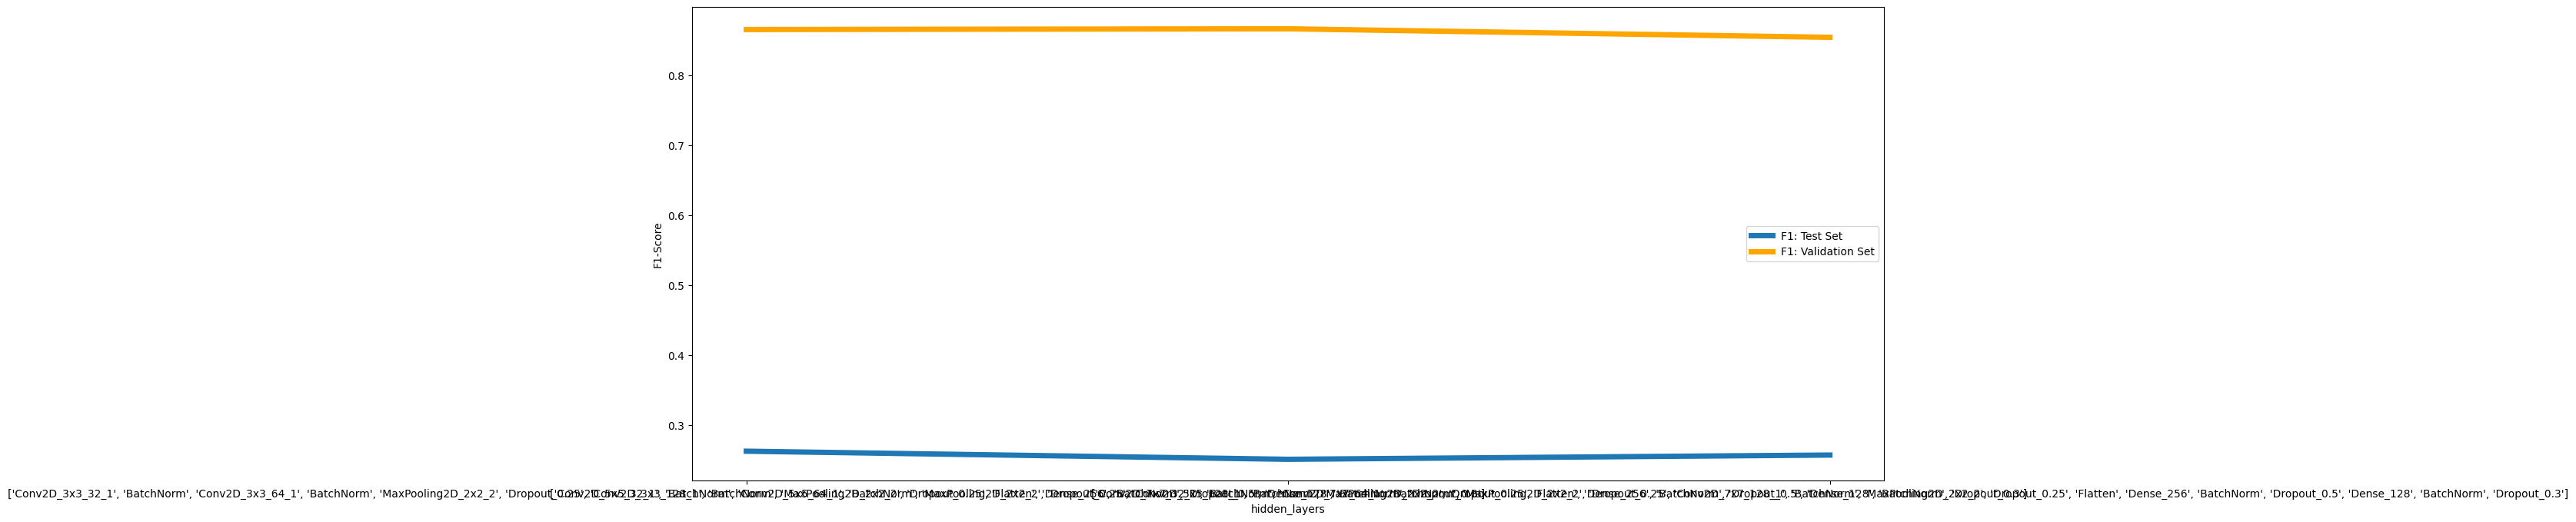

In [55]:
# Kernel size of 3
values_list = [['Conv2D_3x3_32_1', 'BatchNorm', 'Conv2D_3x3_64_1',
                           'BatchNorm', 'MaxPooling2D_2x2_2', 'Dropout_0.25',
                           'Conv2D_3x3_128_1', 'BatchNorm', 'MaxPooling2D_2x2_2',
                           'Dropout_0.25', 'Flatten', 'Dense_256', 'BatchNorm',
                           'Dropout_0.5', 'Dense_128', 'BatchNorm', 'Dropout_0.3']]


# Kernel size of 5
values_list += [['Conv2D_5x5_32_1', 'BatchNorm', 'Conv2D_5x5_64_1',
                           'BatchNorm', 'MaxPooling2D_2x2_2', 'Dropout_0.25',
                           'Conv2D_5x5_128_1', 'BatchNorm', 'MaxPooling2D_2x2_2',
                           'Dropout_0.25', 'Flatten', 'Dense_256', 'BatchNorm',
                           'Dropout_0.5', 'Dense_128', 'BatchNorm', 'Dropout_0.3']]

# Kernel size of 7
values_list += [['Conv2D_7x7_32_1', 'BatchNorm', 'Conv2D_7x7_64_1',
                           'BatchNorm', 'MaxPooling2D_2x2_2', 'Dropout_0.25',
                           'Conv2D_7x7_128_1', 'BatchNorm', 'MaxPooling2D_2x2_2',
                           'Dropout_0.25', 'Flatten', 'Dense_256', 'BatchNorm',
                           'Dropout_0.5', 'Dense_128', 'BatchNorm', 'Dropout_0.3']]

model,best_architecture = evaluate_efect_param(parameter_type='model_params',parameter_name='hidden_layers',values_list=values_list)
kfold_params['model_params']['hidden_layers'] = best_architecture

> In this part we evaluated our model with different kernel sizes 3, 5, 7. As we can see by increasing the kernel size the validation score first increases but again decreases and for the test score it decreases and again increases. But generally it didn't change much the scores.

>Generally, Larger kernels (e.g., 7×7, 11×11) increase capacity because they capture broader spatial context and more complex patterns per layer. Large kernels risk overfitting, especially on small datasets, as they introduce many parameters and may memorize noise. Larger kernels increase computational cost (more multiplications per convolution) and memory usage, slowing training. Small kernels are faster.



2. Strides

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Val: ['Conv2D_3x3_32_1', 'BatchNorm', 'Conv2D_3x3_64_1', 'BatchNorm', 'MaxPooling2D_2x2_2', 'Dropout_0.25', 'Conv2D_3x3_128_1', 'BatchNorm', 'MaxPooling2D_2x2_2', 'Dropout_0.25', 'Flatten', 'Dense_256', 'BatchNorm', 'Dropout_0.5', 'Dense_128', 'BatchNorm', 'Dropout_0.3'], Validation Score: 0.870, Test Score: 0.260
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Val: ['Conv2D_3x3_32_2', 'BatchNorm', 'Conv2D_3x3_64_2', 'BatchNorm', 'MaxPooling2D_2x2_2', 'Dropout_0.25', 'Conv2D_3x3_128_2', 'BatchNorm', 'MaxPooling2D_2x2_2', 'Dropout_0.25', 'Flatten', 'Dense_256', 'BatchNorm', 'Dropout_0.5', 'Dense_128', 'BatchNorm', 'Dropout_0.3'], Validation Score: 0.825, Test Score: 0.253


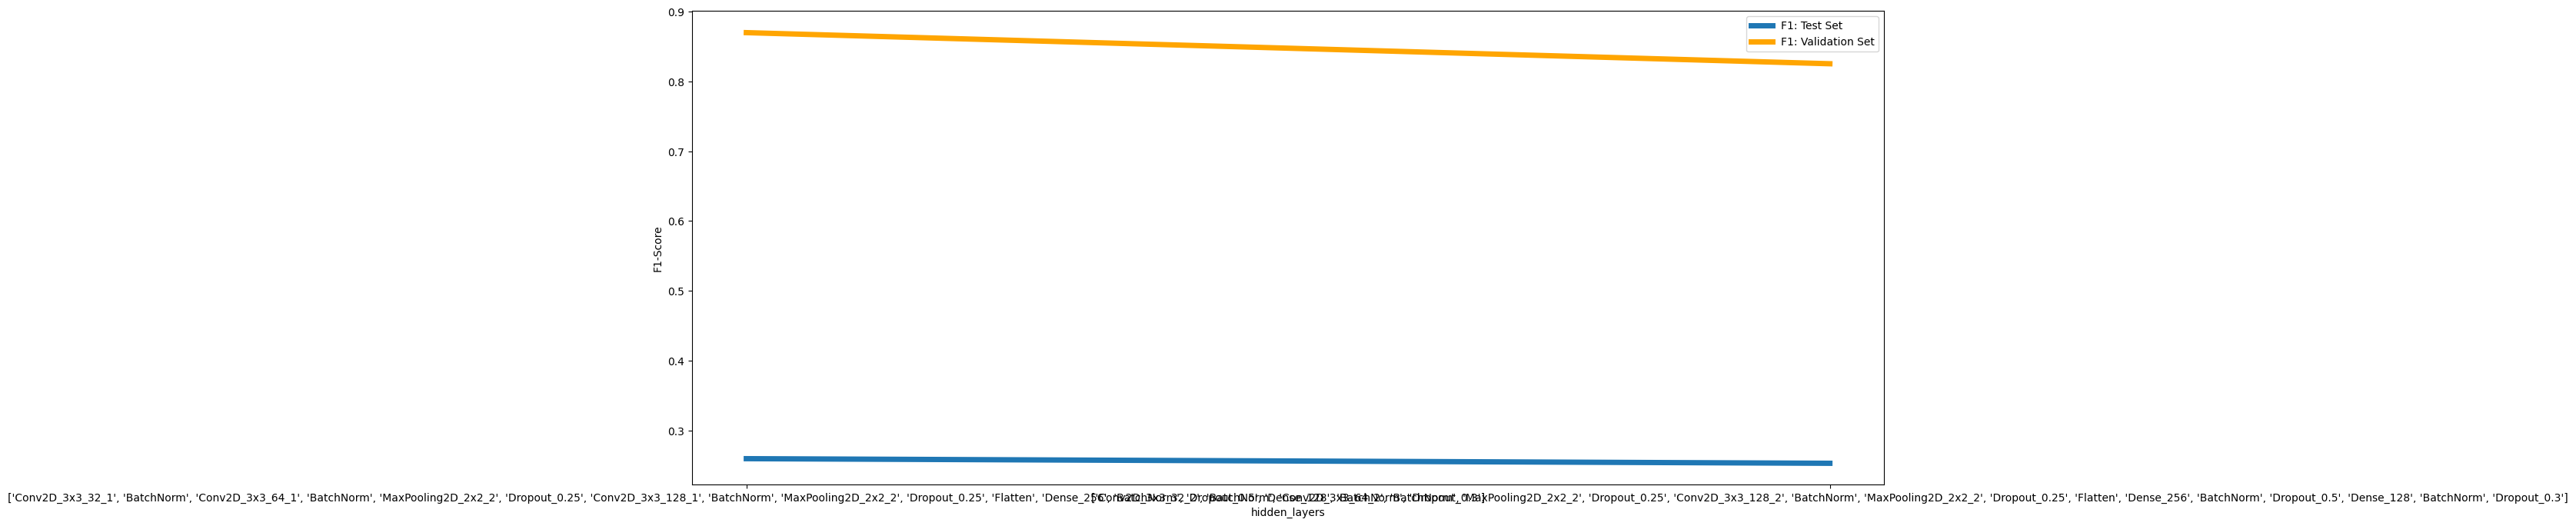

In [60]:
# Stride 1
values_list = [['Conv2D_3x3_32_1', 'BatchNorm', 'Conv2D_3x3_64_1',
                           'BatchNorm', 'MaxPooling2D_2x2_2', 'Dropout_0.25',
                           'Conv2D_3x3_128_1', 'BatchNorm', 'MaxPooling2D_2x2_2',
                           'Dropout_0.25', 'Flatten', 'Dense_256', 'BatchNorm',
                           'Dropout_0.5', 'Dense_128', 'BatchNorm', 'Dropout_0.3']]

# Stride 2
values_list += [['Conv2D_3x3_32_2', 'BatchNorm', 'Conv2D_3x3_64_2',
                           'BatchNorm', 'MaxPooling2D_2x2_2', 'Dropout_0.25',
                           'Conv2D_3x3_128_2', 'BatchNorm', 'MaxPooling2D_2x2_2',
                           'Dropout_0.25', 'Flatten', 'Dense_256', 'BatchNorm',
                           'Dropout_0.5', 'Dense_128', 'BatchNorm', 'Dropout_0.3']]


model,best_architecture = evaluate_efect_param(parameter_type='model_params',parameter_name='hidden_layers',values_list=values_list)
kfold_params['model_params']['hidden_layers'] = best_architecture

> In this part we used 2 different stride values, as we can see by increasing the stride value both validation and test scores decrease.

> Generally, Stride > 1 reduces spatial dimensions early, which lowers capacity because fewer spatial positions are processed. Larger strides (≥2) act as a strong downsampler, reducing the number of parameters and feature map size → helps prevent overfitting. However, too large a stride may discard fine details, causing underfitting (e.g., losing small objects). Higher stride → smaller feature maps → fewer computations → faster training.

3. Numbers of Filters

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Val: ['Conv2D_3x3_32_1', 'BatchNorm', 'Conv2D_3x3_64_1', 'BatchNorm', 'MaxPooling2D_2x2_2', 'Dropout_0.25', 'Conv2D_3x3_128_1', 'BatchNorm', 'MaxPooling2D_2x2_2', 'Dropout_0.25', 'Flatten', 'Dense_256', 'BatchNorm', 'Dropout_0.5', 'Dense_128', 'BatchNorm', 'Dropout_0.3'], Validation Score: 0.846, Test Score: 0.262
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Val: ['Conv2D_3x3_64_1', 'BatchNorm', 'Conv2D_3x3_64_1', 'BatchNorm', 'MaxPooling2D_2x2_2', 'Dropout_0.25', 'Conv2D_3x3_128_1', 'BatchNorm', 'MaxPooling2D_2x2_2', 'Dropout_0.25', 'Flatten', 'Dense_256', 'BatchNorm', 'Dropout_0.5', 'Dense_128', 'BatchNorm', 'Dropout_0.3'], Validation Score: 0.862, Test Score: 0.264


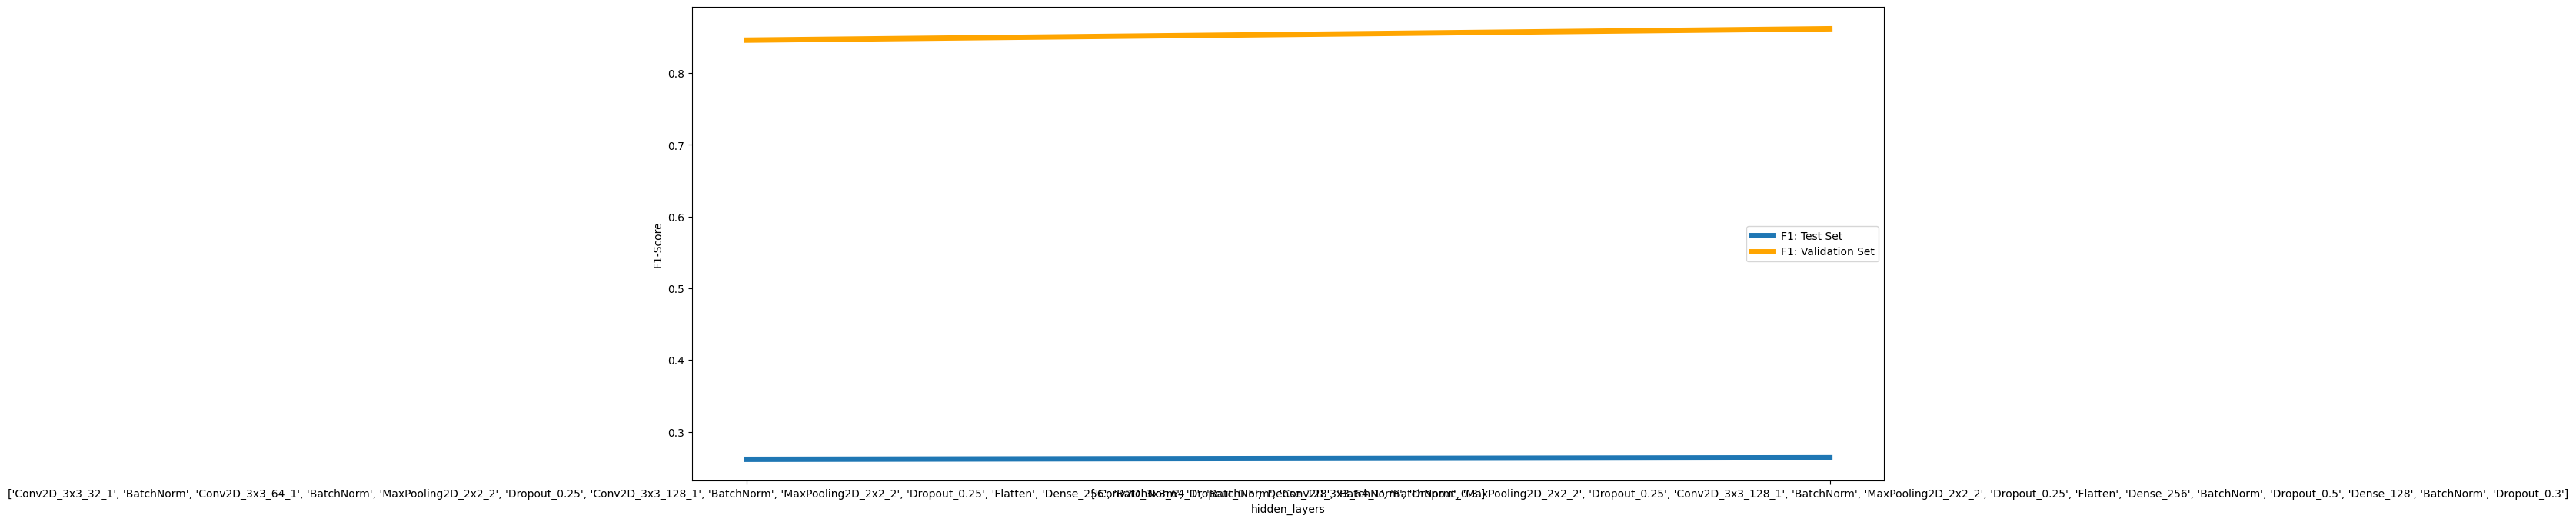

In [61]:
# No. filters = 32
values_list = [['Conv2D_3x3_32_1', 'BatchNorm', 'Conv2D_3x3_64_1',
                           'BatchNorm', 'MaxPooling2D_2x2_2', 'Dropout_0.25',
                           'Conv2D_3x3_128_1', 'BatchNorm', 'MaxPooling2D_2x2_2',
                           'Dropout_0.25', 'Flatten', 'Dense_256', 'BatchNorm',
                           'Dropout_0.5', 'Dense_128', 'BatchNorm', 'Dropout_0.3']]

# No. filters = 64
values_list += [['Conv2D_3x3_64_1', 'BatchNorm', 'Conv2D_3x3_64_1',
                           'BatchNorm', 'MaxPooling2D_2x2_2', 'Dropout_0.25',
                           'Conv2D_3x3_128_1', 'BatchNorm', 'MaxPooling2D_2x2_2',
                           'Dropout_0.25', 'Flatten', 'Dense_256', 'BatchNorm',
                           'Dropout_0.5', 'Dense_128', 'BatchNorm', 'Dropout_0.3']]

model,best_architecture = evaluate_efect_param(parameter_type='model_params',parameter_name='hidden_layers',values_list=values_list)
kfold_params['model_params']['hidden_layers'] = best_architecture

> As we can see by increasing the number of filters both scores increased.

>Generally, More filters per layer increase capacity exponentially (more channels → more feature combinations). Too many filters cause overfitting (model memorizes training data). Too few filters cause underfitting. More filters increase FLOPs and memory (both forward and backward passes), raising training time linearly with filter count. Increasing filters generally improves performance up to a point, after which gains saturate and overfitting degrades validation accuracy.

4. Pooling Types

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Val: ['Conv2D_3x3_32_1', 'BatchNorm', 'Conv2D_3x3_64_1', 'BatchNorm', 'MaxPooling2D_2x2_2', 'Dropout_0.25', 'Conv2D_3x3_128_1', 'BatchNorm', 'MaxPooling2D_2x2_2', 'Dropout_0.25', 'Flatten', 'Dense_256', 'BatchNorm', 'Dropout_0.5', 'Dense_128', 'BatchNorm', 'Dropout_0.3'], Validation Score: 0.902, Test Score: 0.265
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Val: ['Conv2D_3x3_32_1', 'BatchNorm', 'Conv2D_3x3_64_1', 'BatchNorm', 'AveragePooling2D_2x2_2', 'Dropout_0.25', 'Conv2D_3x3_128_1', 'BatchNorm', 'AveragePooling2D_2x2_2', 'Dropout_0.25', 'Flatten', 'Dense_256', 'BatchNorm', 'Dropout_0.5', 'Dense_128', 'BatchNorm', 'Dropout_0.3'], Validation Score: 0.881, Test Score: 0.262


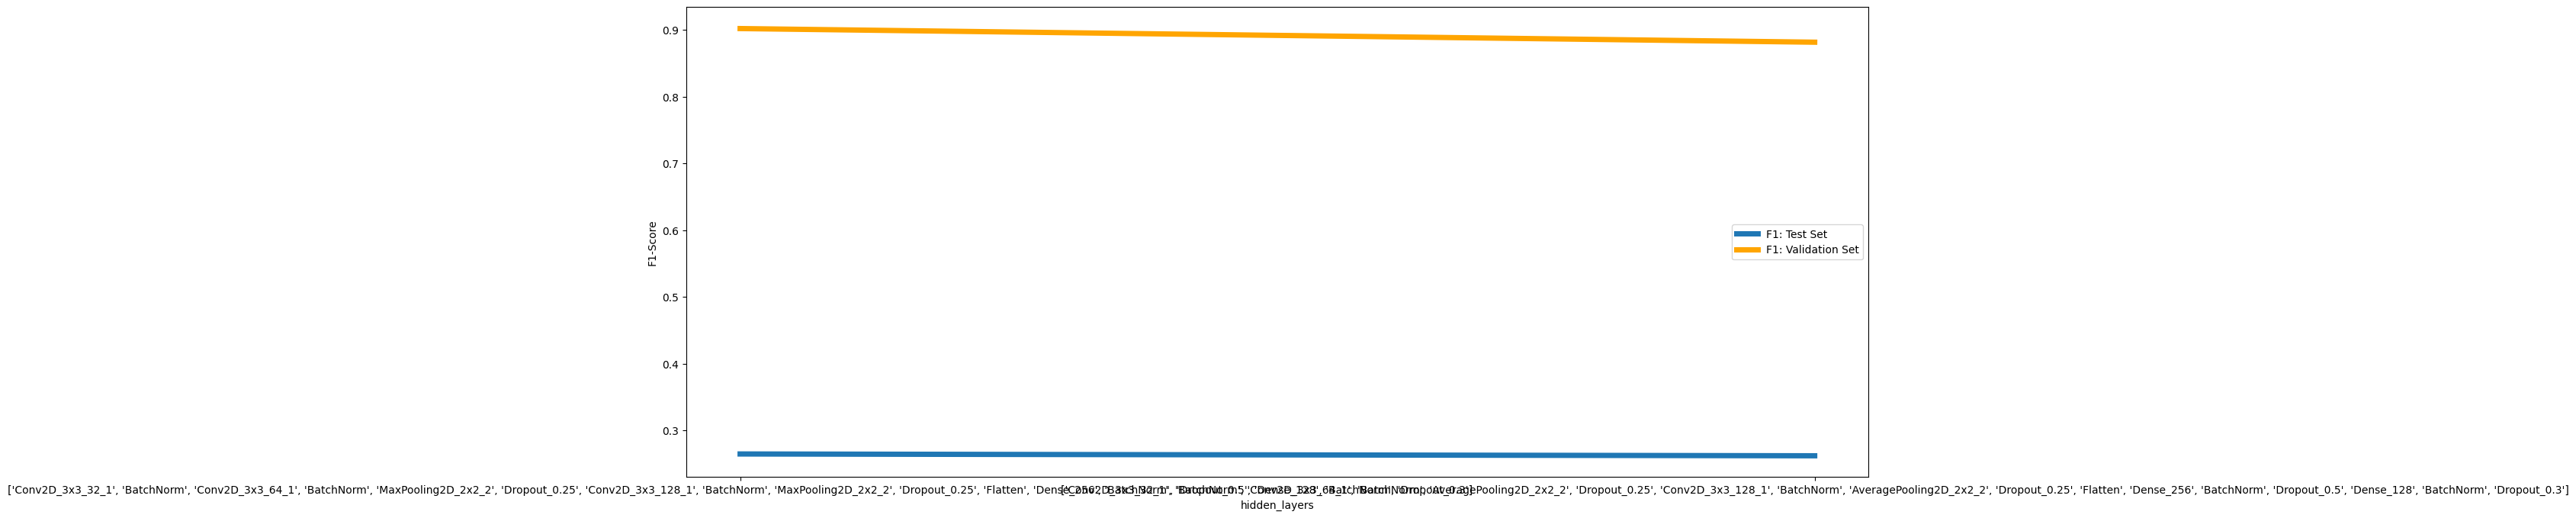

In [16]:
# MaxPooling with stride 0
values_list = [['Conv2D_3x3_32_1', 'BatchNorm', 'Conv2D_3x3_64_1',
                           'BatchNorm', 'MaxPooling2D_2x2_2', 'Dropout_0.25',
                           'Conv2D_3x3_128_1', 'BatchNorm', 'MaxPooling2D_2x2_2',
                           'Dropout_0.25', 'Flatten', 'Dense_256', 'BatchNorm',
                           'Dropout_0.5', 'Dense_128', 'BatchNorm', 'Dropout_0.3']]

# AveragePooling with stride 0
values_list += [['Conv2D_3x3_32_1', 'BatchNorm', 'Conv2D_3x3_64_1',
                           'BatchNorm', 'AveragePooling2D_2x2_2', 'Dropout_0.25',
                           'Conv2D_3x3_128_1', 'BatchNorm', 'AveragePooling2D_2x2_2',
                           'Dropout_0.25', 'Flatten', 'Dense_256', 'BatchNorm',
                           'Dropout_0.5', 'Dense_128', 'BatchNorm', 'Dropout_0.3']]


model,best_architecture = evaluate_efect_param(parameter_type='model_params',parameter_name='hidden_layers',values_list=values_list)
kfold_params['model_params']['hidden_layers'] = best_architecture

> As we can see max pooling has higher scores than average pooling.

>Generally, average pooling is more prone to overfitting, and it is slower and it has higher capacity. Max pooling is usually better for object recognition  preserves edges, textures, and dominant patterns.

5. Depth of Network

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Val: ['Conv2D_3x3_32_1', 'BatchNorm', 'Conv2D_3x3_64_1', 'BatchNorm', 'MaxPooling2D_2x2_2', 'Dropout_0.25', 'Conv2D_3x3_128_1', 'BatchNorm', 'MaxPooling2D_2x2_2', 'Dropout_0.25', 'Flatten', 'Dense_256', 'BatchNorm', 'Dropout_0.5', 'Dense_128', 'BatchNorm', 'Dropout_0.3'], Validation Score: 0.858, Test Score: 0.262
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Val: ['Conv2D_3x3_32_1', 'BatchNorm', 'Conv2D_3x3_64_1', 'BatchNorm', 'MaxPooling2D_2x2_2', 'Dropout_0.25', 'Flatten', 'Dense_128', 'BatchNorm', 'Dropout_0.5'], Validation Score: 0.848, Test Score: 0.262
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 

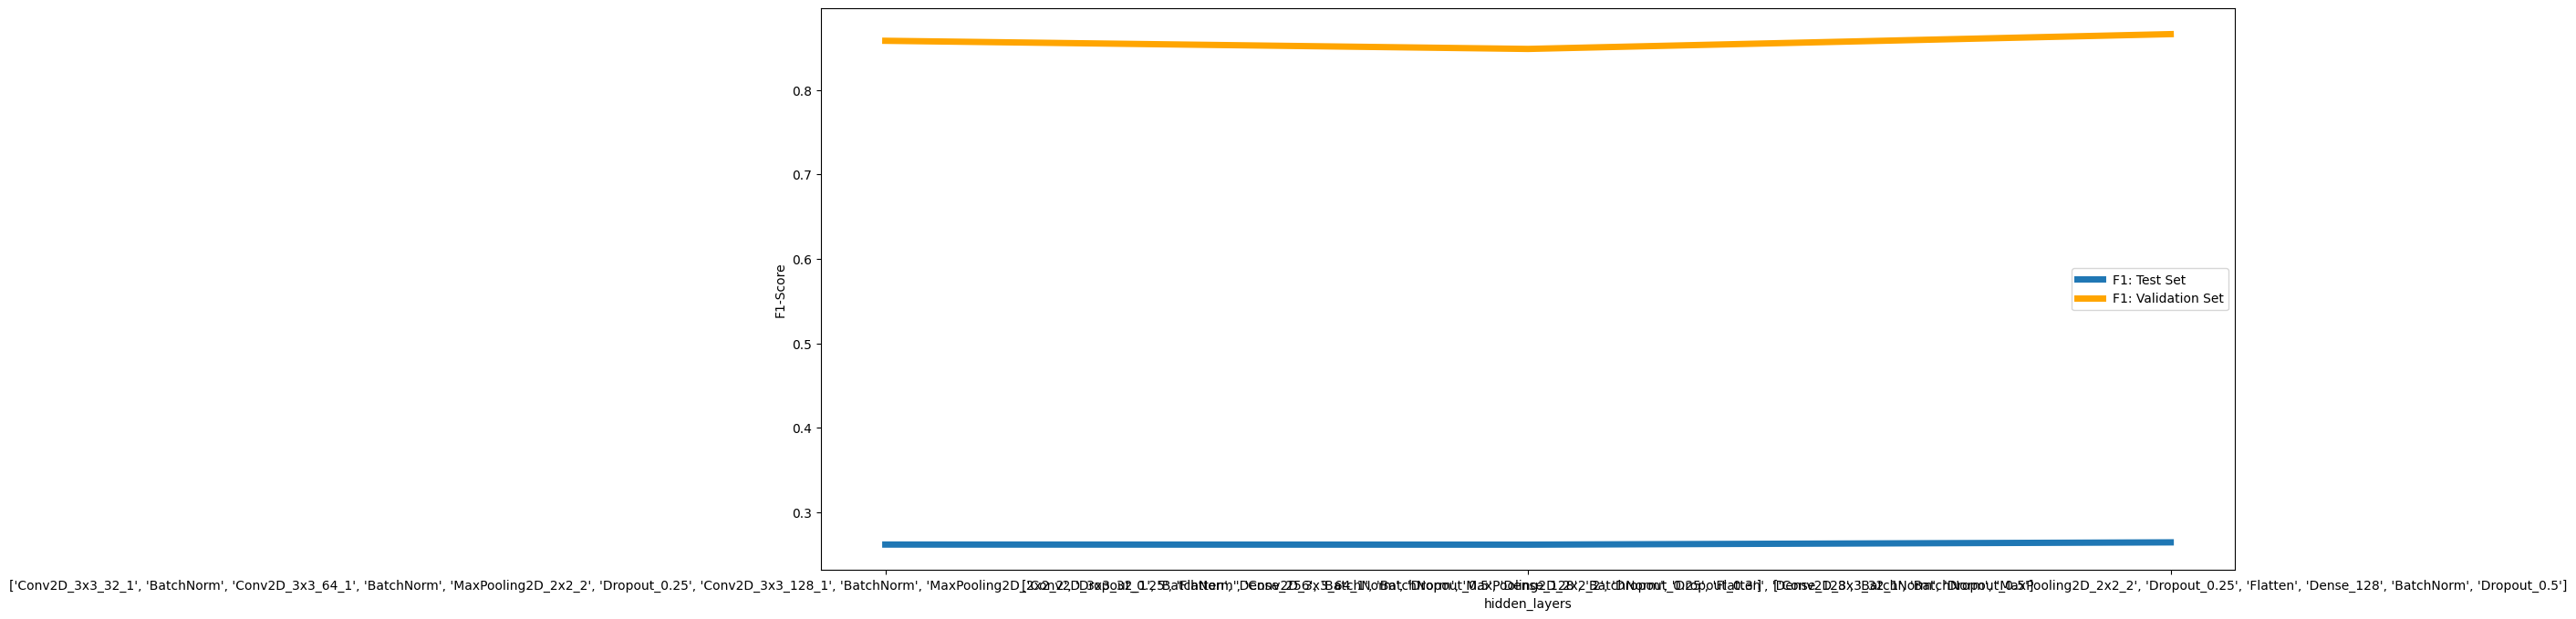

In [22]:
# depth 5
values_list = [['Conv2D_3x3_32_1', 'BatchNorm', 'Conv2D_3x3_64_1',
                           'BatchNorm', 'MaxPooling2D_2x2_2', 'Dropout_0.25',
                           'Conv2D_3x3_128_1', 'BatchNorm', 'MaxPooling2D_2x2_2',
                           'Dropout_0.25', 'Flatten', 'Dense_256', 'BatchNorm',
                           'Dropout_0.5', 'Dense_128', 'BatchNorm', 'Dropout_0.3']]

# depth 3
values_list +=  [['Conv2D_3x3_32_1', 'BatchNorm', 'Conv2D_3x3_64_1',
                             'BatchNorm', 'MaxPooling2D_2x2_2', 'Dropout_0.25',
                             'Flatten', 'Dense_128', 'BatchNorm', 'Dropout_0.5']]

# Depth 2
values_list += [['Conv2D_3x3_32_1', 'BatchNorm', 'MaxPooling2D_2x2_2',
                               'Dropout_0.25', 'Flatten', 'Dense_128', 'BatchNorm', 'Dropout_0.5']]


model,best_architecture = evaluate_efect_param(parameter_type='model_params',parameter_name='hidden_layers',values_list=values_list)
kfold_params['model_params']['hidden_layers'] = best_architecture

> In this part we evaluated our model with different depth sizes, as we can see the validation score first decreases but then increases. The test score is constant from depth 5 to 3 but then increases for depth 2.

> Generally Deeper networks (more layers) dramatically increase capacity because they learn hierarchical representations – from simple edges to complex objects. Shallow networks have low capacity. Deeper models require more sequential operations and more parameters → significantly longer training time and larger memory footprint. Too shallow → cannot learn complex patterns → high bias. Too deep (with insufficient data or no regularization) → model memorizes noise. For performance up to a point, deeper is better (ImageNet winners evolved from 8 layers to >100). Beyond a certain depth, performance saturates or degrades without residual connections. For small datasets, very deep models hurt performance due to overfitting.

## Data Augmentation

In [17]:
datagen_fashion = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,    # Shoes/bags would look weird flipped
    fill_mode='nearest',
    validation_split=0.2
)

In [18]:
train_iterator = datagen_fashion.flow(x_train, y_train_enc,subset='training',batch_size=32)
val_iterator = datagen_fashion.flow(x_train, y_train_enc,subset='validation',batch_size=32)

In [25]:
history = model.fit(
      train_iterator,
      validation_data=val_iterator,
      callbacks=[early_stopping],
      steps_per_epoch=len(train_iterator),
      validation_steps=len(val_iterator),
      verbose=2,
      epochs=10,
)

Epoch 1/10
1500/1500 - 27s - 18ms/step - accuracy: 0.7916 - loss: 0.5634 - val_accuracy: 0.7773 - val_loss: 0.5481
Epoch 2/10
1500/1500 - 37s - 25ms/step - accuracy: 0.8034 - loss: 0.5302 - val_accuracy: 0.8275 - val_loss: 0.4535
Epoch 3/10
1500/1500 - 24s - 16ms/step - accuracy: 0.8074 - loss: 0.5175 - val_accuracy: 0.8443 - val_loss: 0.4113
Epoch 4/10
1500/1500 - 24s - 16ms/step - accuracy: 0.8130 - loss: 0.5015 - val_accuracy: 0.8303 - val_loss: 0.4349
Epoch 5/10
1500/1500 - 24s - 16ms/step - accuracy: 0.8171 - loss: 0.4916 - val_accuracy: 0.8482 - val_loss: 0.4026
Epoch 6/10
1500/1500 - 24s - 16ms/step - accuracy: 0.8197 - loss: 0.4845 - val_accuracy: 0.8495 - val_loss: 0.3912
Epoch 7/10
1500/1500 - 24s - 16ms/step - accuracy: 0.8232 - loss: 0.4763 - val_accuracy: 0.8518 - val_loss: 0.3860
Epoch 8/10
1500/1500 - 24s - 16ms/step - accuracy: 0.8260 - loss: 0.4682 - val_accuracy: 0.8468 - val_loss: 0.4013
Epoch 9/10
1500/1500 - 24s - 16ms/step - accuracy: 0.8285 - loss: 0.4630 - val_a

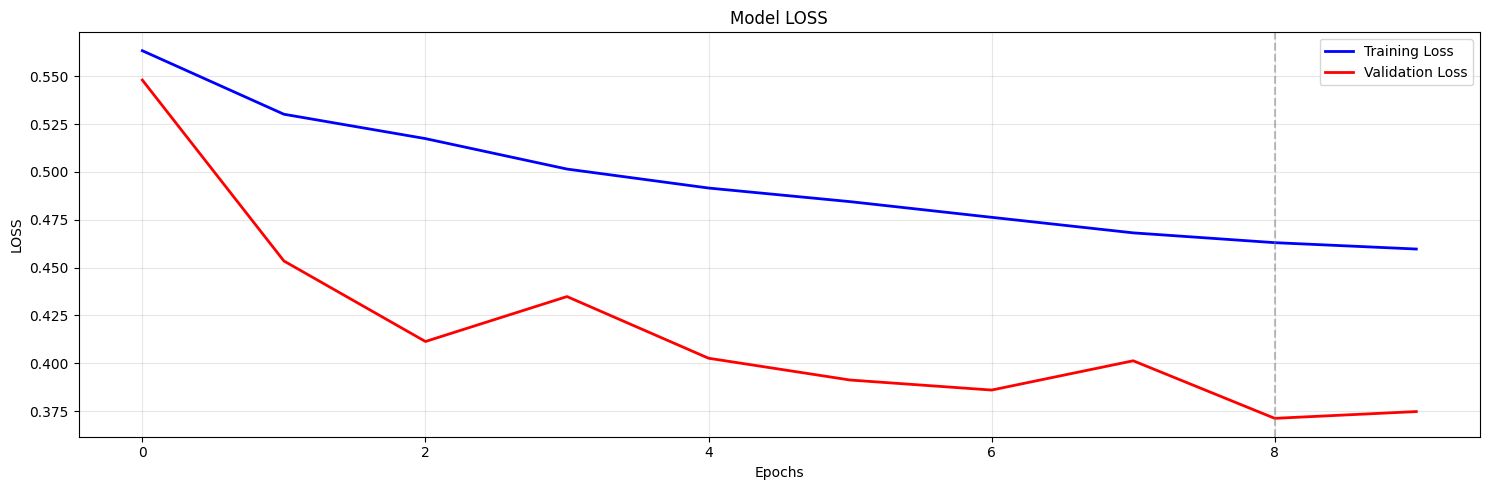

In [26]:
plot_history(history,plot_type='loss')

In [27]:
predictions = model.predict(x_test)
print('Weighted F1-score is %.2f' %f1_score(y_test, convert_predictions(predictions), average='weighted'))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Weighted F1-score is 0.74


In [28]:
print('Top-3accuracy %s' % top_k_accuracy_score(y_test, predictions, k=3))

Top-3accuracy 0.9803



Data Augmentation

>Impact on Overfitting

1. Reduces overfitting

Augmentation creates modified copies of training images (e.g., rotations, flips, crops, color shifts). The model sees different variations of the same underlying sample, making it harder to memorize exact pixel patterns or noise. This increases the effective diversity of the training set without collecting new data, lowering the gap between training and validation error.

2. Acts as an implicit regularizer

By forcing the network to be invariant to irrelevant transformations (e.g., small rotations, lighting changes), augmentation prevents the model from relying on spurious correlations (e.g., a specific texture or object position). This reduces the variance of the model, a key factor in overfitting.

>Impact on Generalization

1. Improves generalization

Augmentation exposes the model to a broader distribution of inputs that resemble real-world variations. Consequently, the model learns more robust and transferable features, leading to better performance on unseen test data. Common augmentations like random cropping mimic different object scales and positions, teaching translation invariance.

2. Helps when data is limited

With small datasets, augmentation is often essential to achieve decent generalization. It artificially expands the training distribution, preventing the high bias/variance trade-off from tipping toward overfitting.

## Transfer Learning Model

In [29]:
def create_transfer_model(base_model, learning_rate=0.001, learning_rate_decay=0.9,
                          no_classes=10):

    model = Sequential()
    model.add(base_model)                      # Add base model
    model.add(GlobalAveragePooling2D())        # Better than Flatten for transfer learning
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(no_classes, activation='softmax'))

    model.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate,
                                           beta_1=learning_rate_decay),
        metrics=['accuracy']
    )
    return model

In [30]:
inputs = tf.keras.Input(shape=x_train.shape[1:])   # (28, 28, 1)
x = tf.keras.layers.Resizing(32, 32)(inputs)       # (32, 32, 1)
x = tf.keras.layers.Lambda(lambda t: tf.repeat(t, 3, axis=-1))(x)  # (32, 32, 3)

# Used VGG19 as base model
base_model = VGG19(
    include_top=False,
    weights='imagenet',
    input_shape=(32, 32, 3),
    classes=y_train_enc.shape[1]
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model(x)  # connect preprocessing → VGG19

base_model = tf.keras.Model(inputs, x)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [31]:
model = create_transfer_model(base_model)
model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional_37 (Functional)      │ (None, 1, 1, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,091,338 (76.64 MB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [32]:
history = model.fit(
      train_iterator,
      validation_data=val_iterator,
      callbacks=[early_stopping],
      verbose=1,
      epochs=2,
)

Epoch 1/2
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 22ms/step - accuracy: 0.7390 - loss: 0.7155 - val_accuracy: 0.7937 - val_loss: 0.5588
Epoch 2/2
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.7850 - loss: 0.5745 - val_accuracy: 0.7989 - val_loss: 0.5318


In [33]:
predictions = model.predict(x_test)
print('Weighted F1-score is %.2f' %f1_score(y_test, convert_predictions(predictions), average='weighted'))

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step
Weighted F1-score is 0.79


In [34]:
print('Top-3accuracy %s' % top_k_accuracy_score(y_test, predictions, k=3))

Top-3accuracy 0.9614


>Chosen model: VGG19

Why:

1. Availability & compatibility – VGG19 is a standard model in tf.keras.applications, well‑documented and easy to use.

2. Feature extraction strength – VGG19’s early layers learn generic features (edges, textures, simple shapes) that transfer reasonably well to clothing patterns in Fashion‑MNIST, even though the domain differs (natural images → grayscale fashion items).


I freezed all layers, so the model acts as a fixed feature extractor – Pre‑trained ImageNet weights are kept unchanged. Only the newly added classifier head (pooling + dense layers) will be trained. Alos prevent overfitting – Fashion‑MNIST is small (60k images). Freezing reduces the number of trainable parameters from ~20 million to only a few thousand (the Dense layers), acting as a strong regularizer.

Comparing this model to my CNN model, the CNN model outperforms this model, comparing the f1 scores. Here are some reasons:

- Domain mismatch: VGG19 trained on natural images, Fashion‑MNIST is grayscale clothing.

- Forced small input (32×32) wastes VGG19’s capacity (designed for 224×224).

- Frozen layers provide generic features that don’t adapt to clothing‑specific patterns.

- Custom CNN (with 2–3 conv layers) learns optimized features from scratch for this dataset.

- Fashion‑MNIST (60k images) is large enough for a custom CNN to generalize well without transfer learning.

# Why CNNs are more parameter-efficient than MLPs for images

Convolutional Neural Networks (CNNs) are fundamentally more parameter-efficient than Multi-Layer Perceptrons (MLPs) for high-dimensional inputs like images due to two key architectural principles:

1. **Local connectivity**  
   Each neuron in a CNN's convolutional layer connects only to a small local region of the input (e.g., a 3×3 patch), not to all input neurons. This reduces the number of connections and parameters dramatically compared to fully connected layers, where every input neuron connects to every output neuron.

2. **Weight sharing**  
   The same filter (set of weights) is slid across the entire spatial extent of the input. Thus, a single set of parameters is reused for all positions, learning translation-equivariant features. In an MLP, weights are unique for each input–output pair, so the number of parameters grows with the product of input and output dimensions.

For an image of size $H \times W \times C$ and an MLP hidden layer with $K$ neurons, the parameter count is $O(HWC \cdot K)$. A CNN with $F$ filters of size $k \times k \times C$ has only $O(k^2 C F)$ parameters, independent of $H$ and $W$. This difference becomes astronomical for high-resolution images.

---

## Theoretical conditions for an MLP to match CNN performance

An MLP could theoretically match a CNN's performance if:

- **Infinite data** is available to learn all necessary spatial invariances (e.g., translations, local patterns) from scratch, without explicit inductive biases.
- **Sufficient model capacity** (many hidden layers and neurons) is provided to represent the same functions as a CNN. Since CNNs are a subset of all possible functions (weight sharing imposes structural constraints), an MLP with enough parameters can approximate any CNN arbitrarily well (universal approximation theorem).
- **Perfect regularization** is applied to force the MLP to learn the specific weight‑tying patterns that mimic convolution. Without such regularization, the MLP would likely discover different, less efficient solutions.

---

## Why this is unrealistic in practical scenarios

- **Parameter explosion**  
  For a modest 224×224×3 image, an MLP with a single hidden layer of size 224×224 would have roughly $150k \times 150k \approx 22.5$ billion parameters – requiring petabytes of memory and infeasible computation. Even with modern hardware, such models are untrainable.

- **Data inefficiency**  
  An MLP must learn translation invariance by seeing every object at every possible position in the training set. For real‑world images, the number of required training samples grows exponentially with the input dimension. CNNs, by contrast, generalize from far fewer examples because their architecture already encodes translation equivariance.

- **Optimization difficulty**  
  Deep MLPs suffer from vanishing/exploding gradients and require careful initialization and normalization. The lack of built‑in spatial structure makes loss landscapes highly non‑convex and hard to navigate, leading to suboptimal convergence.

- **No locality prior**  
  An MLP treats all pixel pairs equally, regardless of their distance. This wastes capacity on learning that nearby pixels are more correlated – a fact that CNNs exploit directly. In practice, even with massive datasets, MLPs tend to overfit or require prohibitive amounts of computation to match CNN performance on tasks like image classification.

> **Conclusion:** While an MLP *could* theoretically emulate a CNN, the combinatorial explosion in parameters and data requirements makes it utterly impractical for real‑world high‑dimensional inputs.